# Day 1 Walkthrough: From A Table To A Prediction

This hour builds one complete machine learning workflow from beginning to end.
We start with a table of measurements, look at it properly, refresh the
statistics that the rest of the week depends on, and then fit four models to
it. Nothing here is advanced. The point is to fix the shape of the workflow in
your mind, because every later day repeats this same shape on harder data.

The dataset records body measurements of 344 penguins from three species,
collected at Palmer Station in Antarctica. It is small enough to read on one
screen and rich enough to demonstrate every idea we need.

| Section | Minutes |
| --- | --- |
| Orientation | 5 |
| 1. Look At The Data Before You Model It | 10 |
| 2. A Statistics Refresher | 12 |
| 3. Linear Regression | 12 |
| 4. Logistic Regression | 10 |
| 5. Decision Trees And Random Forests | 10 |
| 6. What To Take Away | 1 |

## Orientation (5 Minutes)

A notebook is a sequence of cells. A cell holds either text or code, and you
run the selected one by pressing Shift and Enter together. Running a code cell
sends it to a Python process called the kernel, which keeps every variable you
have created so far.

That last detail causes most of the confusion beginners have with notebooks.
The kernel remembers the order in which you actually ran the cells, not the
order in which they appear on the page. If a notebook starts behaving in a way
that makes no sense, choose Restart Kernel and Run All Cells from the Kernel
menu. That forces the two orders to agree, and it resolves the problem far more
often than reading the code again does.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Every notebook resolves its data through a path relative to itself, so the
# materials work the same way on JupyterHub and on a laptop.
DATA_DIR = Path.cwd().parent / "data"

# Fixing the seed makes every random choice below reproducible, which means
# your numbers will match the ones in the text.
RANDOM_STATE = 42

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 100)

print("Reading data from:", DATA_DIR)

Reading data from: /Users/dimitar.peshevski/workspace/ml-workshop/Day 1 - Introduction and Review/data


## 1. Look At The Data Before You Model It (10 Minutes)

The single most common mistake in applied machine learning is to fit a model to
a table nobody has looked at. Every question below takes seconds to answer and
each one has ended somebody's project when it went unasked.

In [2]:
penguins = pd.read_csv(DATA_DIR / "penguins.csv")

print("Rows:", len(penguins))
print("Columns:", list(penguins.columns))
penguins.head()

Rows: 344
Columns: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


Seven columns. Three of them are categorical, meaning they take one of a small
set of names, and four are numeric measurements in millimetres or grams.
`info` confirms how pandas has interpreted each one.

In [3]:
penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


### Which Values Are Missing?

`info` already hinted at this, because several columns report fewer non-null
entries than there are rows. Counting the gaps directly is clearer.

In [4]:
penguins.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Two rows are missing every measurement, and eleven are missing the recorded
sex. Those eleven include the two empty rows, so nine penguins were measured
but not sexed.

There is no universally correct response to a gap. Dropping the row discards
information that the other columns still hold, and filling the gap invents a
value that was never observed. What you must never do is let the choice happen
by accident, which is exactly what occurs when you never look. Tomorrow's
session is devoted to this question. Today we drop the incomplete rows, because
with eleven of them out of 344 the decision cannot distort anything.

In [5]:
penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


Read the row labelled `min` and the row labelled `max` before any of the
others. Body mass runs from 2700 to 6300 grams and flipper length from 172 to
231 millimetres, which are plausible figures for a seabird. When a physical
measurement reports a minimum of zero or a negative maximum, you have found a
data quality problem rather than a biological fact.

In [6]:
for column in ["species", "island", "sex"]:
    print(penguins[column].value_counts(dropna=False).to_string(), "\n")

species
Adelie       152
Gentoo       124
Chinstrap     68 

island
Biscoe       168
Dream        124
Torgersen     52 

sex
MALE      168
FEMALE    165
NaN        11 



The three species are unevenly represented, with Chinstrap accounting for fewer
than half as many birds as Adelie. That imbalance matters once we start
measuring accuracy, and we return to it in Section 4.

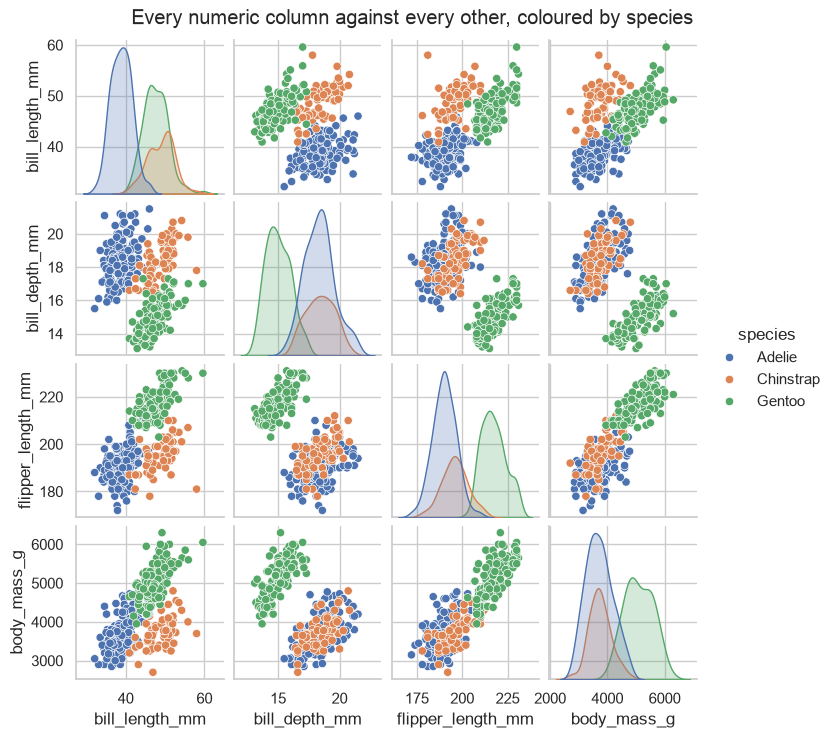

In [7]:
sns.pairplot(
    penguins.dropna(),
    hue="species",
    vars=["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"],
    height=1.8,
)
plt.suptitle("Every numeric column against every other, coloured by species", y=1.02)
plt.show()

This one figure answers most of the questions we are about to ask. Flipper
length and body mass rise together in a tight, almost straight band, which
tells us a linear model of mass will work well. The species form visibly
separate clusters, which tells us classifying them will be close to trivial.

Look at the panel comparing bill length with bill depth, in the upper area of
the grid. Each species forms its own upward-sloping cluster, yet the three
clusters are stacked in a way that makes the overall picture slope downward.
That panel is the subject of the next section.

## 2. A Statistics Refresher (12 Minutes)

Four ideas carry most of the weight in this workshop. They are the centre of a
distribution, its spread, the association between two variables, and the
uncertainty attached to any number you compute from a sample.

### The Centre And Why There Are Two Of Them?

The mean adds every value and divides by the count. The median sorts the values
and takes the middle one. On symmetric data they nearly agree, so the
distinction looks academic until a single wrong value arrives.

In [8]:
mass = penguins["body_mass_g"].dropna()

print(f"mean:   {mass.mean():.1f} g")
print(f"median: {mass.median():.1f} g")

# One penguin is recorded in milligrams instead of grams, a transcription
# error of exactly the kind that reaches real datasets.
corrupted = pd.concat([mass, pd.Series([4200000.0])], ignore_index=True)

print("\nAfter one bad row is added:")
print(
    f"mean:   {corrupted.mean():.1f} g   <- moved by {corrupted.mean() - mass.mean():.0f} g"
)
print(
    f"median: {corrupted.median():.1f} g   <- moved by {corrupted.median() - mass.median():.0f} g"
)

mean:   4201.8 g
median: 4050.0 g

After one bad row is added:
mean:   16434.4 g   <- moved by 12233 g
median: 4050.0 g   <- moved by 0 g


One bad row out of 343 moves the mean by more than twelve thousand grams, which
is roughly three times the mass of an actual penguin. It leaves the median
exactly where it was. The median only cares which value sits in the middle
after sorting, so the size of the wrong number is irrelevant to it. Report the
median whenever you are not yet certain the data is clean.

### The Spread

A centre without a spread is close to useless, because it cannot distinguish a
population where every bird weighs 4200 grams from one where half weigh 2700
and half weigh 5700.

standard deviation: 802.0 g
interquartile range: 1200.0 g


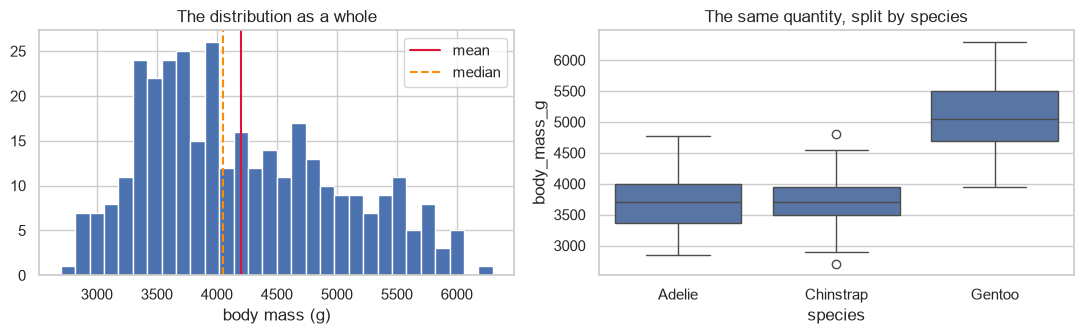

In [9]:
print(f"standard deviation: {mass.std():.1f} g")
print(f"interquartile range: {mass.quantile(0.75) - mass.quantile(0.25):.1f} g")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(mass, bins=30, edgecolor="white")
axes[0].axvline(mass.mean(), color="crimson", label="mean")
axes[0].axvline(mass.median(), color="darkorange", linestyle="--", label="median")
axes[0].set_xlabel("body mass (g)")
axes[0].set_title("The distribution as a whole")
axes[0].legend()

sns.boxplot(data=penguins.dropna(), x="species", y="body_mass_g", ax=axes[1])
axes[1].set_title("The same quantity, split by species")
plt.tight_layout()
plt.show()

The histogram on the left has two humps, and the box plot on the right explains
why. Gentoo penguins are simply heavier than the other two species. A single
mean computed across all 333 birds describes none of the three groups. Whenever
a distribution has more than one hump, look for the variable that separates
them before you summarise it.

### Association And The Trap Hiding In It

Correlation measures how reliably two variables move together on a scale from
minus one to plus one. It is the most useful single number in exploratory work
and the easiest one to misread.

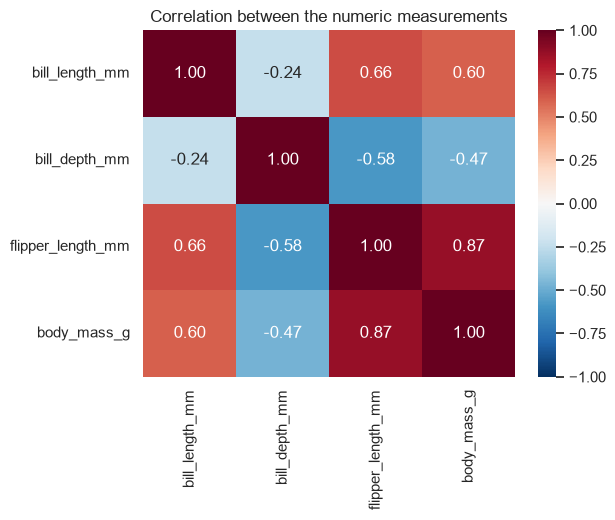

In [10]:
numeric = penguins.select_dtypes("number")

plt.figure(figsize=(6, 4.5))
sns.heatmap(
    numeric.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1
)
plt.title("Correlation between the numeric measurements")
plt.show()

Flipper length and body mass correlate at 0.87, which is the tight band we
already saw. Now look at bill length against bill depth, which comes out
negative. Taken at face value it says that penguins with longer bills have
shallower ones.

Let us check that claim within each species separately.

In [11]:
overall = penguins["bill_length_mm"].corr(penguins["bill_depth_mm"])
print(f"Across all penguins:      r = {overall:+.3f}")

print("\nWithin each species:")
for species, group in penguins.groupby("species"):
    r = group["bill_length_mm"].corr(group["bill_depth_mm"])
    print(f"  {species:<10s} r = {r:+.3f}   (n = {len(group)})")

Across all penguins:      r = -0.235

Within each species:
  Adelie     r = +0.391   (n = 152)
  Chinstrap  r = +0.654   (n = 68)
  Gentoo     r = +0.643   (n = 124)


The association is negative overall and positive inside every single group. The
conclusion reverses depending on whether you account for species, and both
calculations are arithmetically correct.

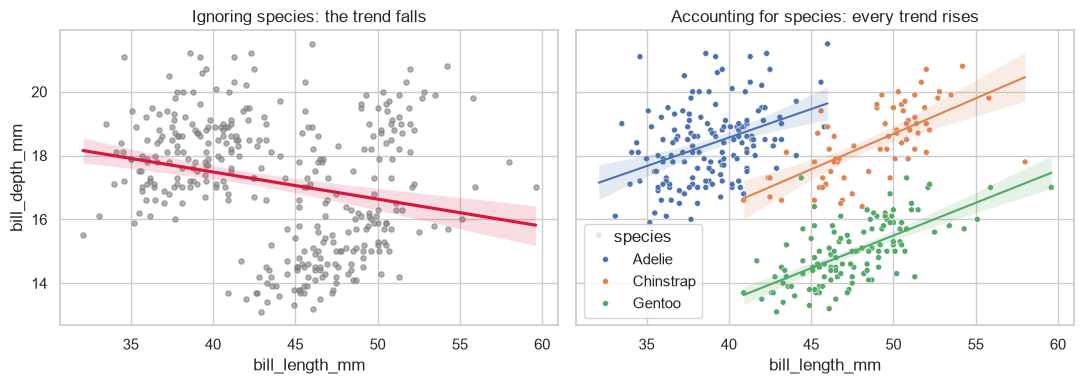

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)

sns.regplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    ax=axes[0],
    scatter_kws={"s": 14, "alpha": 0.6, "color": "grey"},
    line_kws={"color": "crimson"},
)
axes[0].set_title("Ignoring species: the trend falls")

sns.scatterplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    ax=axes[1],
    s=18,
)
for species, group in penguins.groupby("species"):
    sns.regplot(
        data=group,
        x="bill_length_mm",
        y="bill_depth_mm",
        ax=axes[1],
        scatter=False,
        line_kws={"linewidth": 1.5},
    )
axes[1].set_title("Accounting for species: every trend rises")

plt.tight_layout()
plt.show()

This reversal is called Simpson's paradox. It happens whenever a group variable
influences both of the quantities being compared, and it is the reason that a
correlation on its own is never evidence of a cause. Gentoo penguins have long,
shallow bills and Adelie penguins have short, deep ones. Pooling the species
mixes that between-group difference into what looks like a within-group trend.

The practical rule is short. Before you trust an association, ask which groups
the rows fall into, and compute the association again inside each one.

### How Certain Is A Number Computed From A Sample

The mean mass of these 333 penguins is a fact about these 333 penguins. Treated
as an estimate of the species as a whole it carries uncertainty, and a
resampling method called the bootstrap measures that uncertainty without
requiring any formula.

The idea is to imitate the act of collecting the sample again. We draw 333
birds from our data at random with replacement, take the mean, and repeat.

Sample mean:             4201.8 g
95% confidence interval: 4116.8 g to 4287.6 g


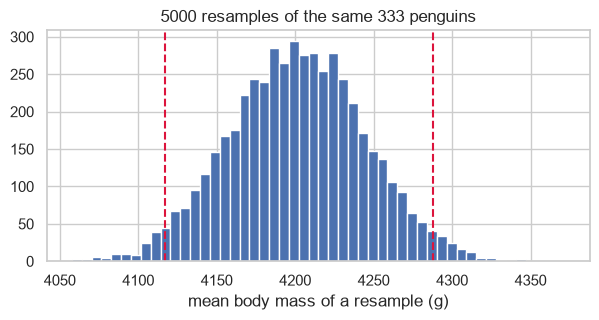

In [13]:
rng = np.random.default_rng(RANDOM_STATE)
values = mass.to_numpy()

bootstrap_means = np.array(
    [rng.choice(values, size=len(values), replace=True).mean() for _ in range(5000)]
)

low, high = np.percentile(bootstrap_means, [2.5, 97.5])
print(f"Sample mean:             {values.mean():.1f} g")
print(f"95% confidence interval: {low:.1f} g to {high:.1f} g")

plt.figure(figsize=(7, 3))
plt.hist(bootstrap_means, bins=50, edgecolor="white")
plt.axvline(low, color="crimson", linestyle="--")
plt.axvline(high, color="crimson", linestyle="--")
plt.xlabel("mean body mass of a resample (g)")
plt.title("5000 resamples of the same 333 penguins")
plt.show()

The interval spans roughly 170 grams. Any claim that rests on a difference in
mean mass smaller than that is not supported by this sample. Carry the habit
into model evaluation: when two models differ by less than the noise, they have
not been shown to differ at all.

## 3. Linear Regression (12 Minutes)

Our first prediction task is to estimate a penguin's body mass in grams from
its other measurements. The target is a continuous number, which makes this a
regression problem.

In [14]:
clean = penguins.dropna().reset_index(drop=True)
print(f"Rows available for modelling: {len(clean)}")

Rows available for modelling: 333


### Splitting Before Fitting

A model's score on the data it learned from is not evidence that it works, in
the same way that an exam made up of questions the student has already seen is
not evidence they understood the subject. We therefore hold part of the data
back before doing anything else.

In [15]:
from sklearn.model_selection import train_test_split

X = clean[["flipper_length_mm"]]
y = clean["body_mass_g"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Training on {len(X_train)} penguins, testing on {len(X_test)}.")

Training on 266 penguins, testing on 67.


In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression().fit(X_train, y_train)

print(f"slope:     {model.coef_[0]:.1f} g per mm")
print(f"intercept: {model.intercept_:.1f} g")

slope:     50.4 g per mm
intercept: -5919.3 g


The slope is the part worth reading aloud. It says that two penguins whose
flippers differ by one millimetre differ in mass by about 50 grams on average.
That is a statement a biologist can agree or disagree with, which is precisely
what makes linear regression valuable even when a more accurate model exists.

The intercept is the predicted mass of a penguin with a flipper of length zero.
It comes out around minus 5900 grams. This is not a defect. It simply means the
line was never fitted anywhere near a flipper length of zero, and you should
not read a fitted model outside the range of the data it saw.

### Scoring The Model And What To Compare It Against?

Three numbers are usual for regression. Mean absolute error is the average size
of a miss in the original units. Root mean squared error is similar but
punishes large misses much harder. R squared reports the fraction of the
variation the model accounts for, on a scale where 1.0 is perfect.

A score means nothing on its own, so we compute the same numbers for a model
that ignores every feature and always predicts the training mean.

In [17]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

baseline = DummyRegressor(strategy="mean").fit(X_train, y_train)

for name, fitted in [("always the mean", baseline), ("linear regression", model)]:
    predicted = fitted.predict(X_test)
    print(
        f"{name:<20s} "
        f"MAE {mean_absolute_error(y_test, predicted):7.1f} g   "
        f"RMSE {root_mean_squared_error(y_test, predicted):7.1f} g   "
        f"R2 {r2_score(y_test, predicted):6.3f}"
    )

always the mean      MAE   674.1 g   RMSE   794.6 g   R2 -0.002


linear regression    MAE   290.1 g   RMSE   360.4 g   R2  0.794


The model is wrong by about 290 grams on a typical penguin, against 674 grams
for guessing the mean. It has more than halved the error, and it accounts for
about 79 percent of the variation.

Always produce this comparison. A model that cannot beat the mean has learned
nothing, and without the baseline printed next to it an R squared of 0.79 is
just a number with no scale attached.

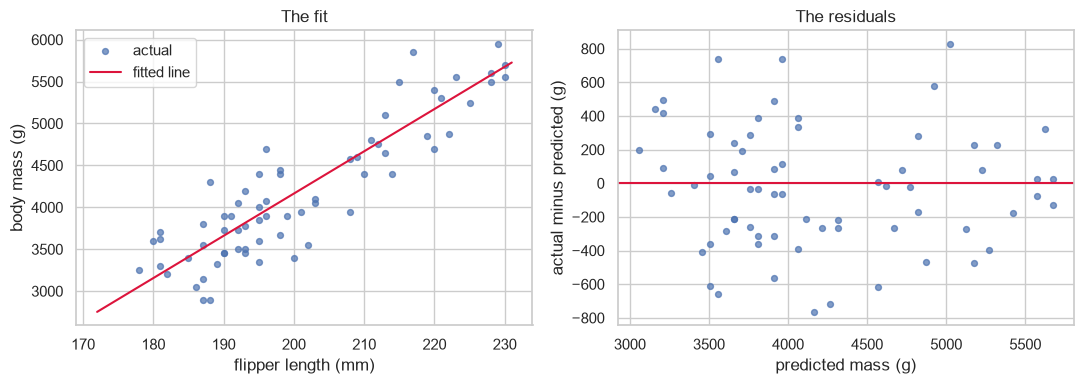

In [18]:
predicted = model.predict(X_test)
residuals = y_test - predicted

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(X_test["flipper_length_mm"], y_test, s=18, alpha=0.7, label="actual")
grid = np.linspace(X["flipper_length_mm"].min(), X["flipper_length_mm"].max(), 100)
axes[0].plot(
    grid,
    model.predict(pd.DataFrame({"flipper_length_mm": grid})),
    color="crimson",
    label="fitted line",
)
axes[0].set_xlabel("flipper length (mm)")
axes[0].set_ylabel("body mass (g)")
axes[0].set_title("The fit")
axes[0].legend()

axes[1].scatter(predicted, residuals, s=18, alpha=0.7)
axes[1].axhline(0, color="crimson")
axes[1].set_xlabel("predicted mass (g)")
axes[1].set_ylabel("actual minus predicted (g)")
axes[1].set_title("The residuals")

plt.tight_layout()
plt.show()

The residual plot on the right is the diagnostic that matters. You want a
shapeless band centred on zero, which is roughly what we have. A curve in that
plot would mean the relationship is not straight, and a funnel that widens to
the right would mean the model is less reliable for heavier birds. Neither is
visible here, so a straight line was a fair description.

### Does Adding Features Help?

It is tempting to assume that more columns produce a better model. Let us
measure it rather than assume it.

In [19]:
feature_sets = {
    "flipper only": ["flipper_length_mm"],
    "flipper, bill length, bill depth": [
        "flipper_length_mm",
        "bill_length_mm",
        "bill_depth_mm",
    ],
}

for label, features in feature_sets.items():
    X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
        clean[features], y, test_size=0.2, random_state=RANDOM_STATE
    )
    fitted = LinearRegression().fit(X_train_f, y_train_f)
    guess = fitted.predict(X_test_f)
    print(
        f"{label:<35s} "
        f"MAE {mean_absolute_error(y_test_f, guess):7.1f} g   "
        f"R2 {r2_score(y_test_f, guess):6.3f}"
    )

flipper only                        MAE   290.1 g   R2  0.794
flipper, bill length, bill depth    MAE   289.7 g   R2  0.798


Two extra columns moved R squared from 0.794 to 0.798, a difference far smaller
than the uncertainty we measured with the bootstrap earlier. The honest
conclusion is that the extra features added nothing, and that flipper length
already carried the signal. Preferring the simpler model here is not modesty,
it is accuracy.

## 4. Logistic Regression (10 Minutes)

Now we predict a category instead of a number. Species would be too easy,
because the pair plot showed the three species already separated. We predict
sex instead, which is genuinely difficult, since male and female penguins of
the same species overlap heavily in every measurement.

Despite its name, logistic regression is a classifier. It fits a straight
boundary like linear regression does, then passes the result through a function
that squashes it into a probability between zero and one.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

features = pd.get_dummies(
    clean[
        [
            "bill_length_mm",
            "bill_depth_mm",
            "flipper_length_mm",
            "body_mass_g",
            "species",
        ]
    ],
    columns=["species"],
    drop_first=True,
    dtype=int,
)
target = (clean["sex"] == "MALE").astype(int)

print("Feature columns:", list(features.columns))
print("Share of the data that is male:", round(target.mean(), 3))

Feature columns: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'species_Chinstrap', 'species_Gentoo']
Share of the data that is male: 0.505


Species is a name rather than a number, so `get_dummies` converts it into
indicator columns holding zero or one. We drop the first category because it is
implied by the others being zero, which keeps the columns from being redundant.

The measurements are on wildly different scales, since body mass runs into the
thousands while bill depth stays under twenty. Logistic regression is sensitive
to that, so we standardise every column to a mean of zero and a standard
deviation of one. Wrapping the scaler and the model in a pipeline guarantees
the scaling is learned on the training data alone. Doing it by hand across the
whole table before splitting would leak information about the test set into
training, which is one of the most common ways an evaluation is quietly
invalidated.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=RANDOM_STATE, stratify=target
)

classifier = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
classifier.fit(X_train, y_train)

print(f"Accuracy on held-out penguins: {classifier.score(X_test, y_test):.3f}")

Accuracy on held-out penguins: 0.896


### Probabilities, Not Just Labels

The model does not really answer male or female. It answers with a probability,
and a threshold of one half turns that into a label. Keeping the probability is
often far more useful, because it tells you which predictions the model is
unsure about.

In [22]:
probabilities = classifier.predict_proba(X_test)[:, 1]

preview = pd.DataFrame(
    {
        "probability of male": probabilities.round(3),
        "predicted": np.where(probabilities > 0.5, "MALE", "FEMALE"),
        "actual": np.where(y_test == 1, "MALE", "FEMALE"),
    }
).head(8)
preview

,probability of male,predicted,actual
0,0.975,MALE,MALE
1,0.005,FEMALE,FEMALE
2,0.993,MALE,MALE
3,0.126,FEMALE,FEMALE
4,0.019,FEMALE,FEMALE
5,0.731,MALE,FEMALE
6,0.996,MALE,MALE
7,0.654,MALE,MALE


### Choosing A Metric

Accuracy is the fraction of predictions that were right. It is the obvious
metric and frequently the wrong one, because it treats both kinds of mistake as
equally costly. Precision asks how many of the penguins called male really were
male. Recall asks how many of the actual males the model found. Which of the
two matters depends entirely on what the prediction is used for.

              precision    recall  f1-score   support

      FEMALE       0.93      0.85      0.89        33
        MALE       0.86      0.94      0.90        34

    accuracy                           0.90        67
   macro avg       0.90      0.89      0.90        67
weighted avg       0.90      0.90      0.90        67



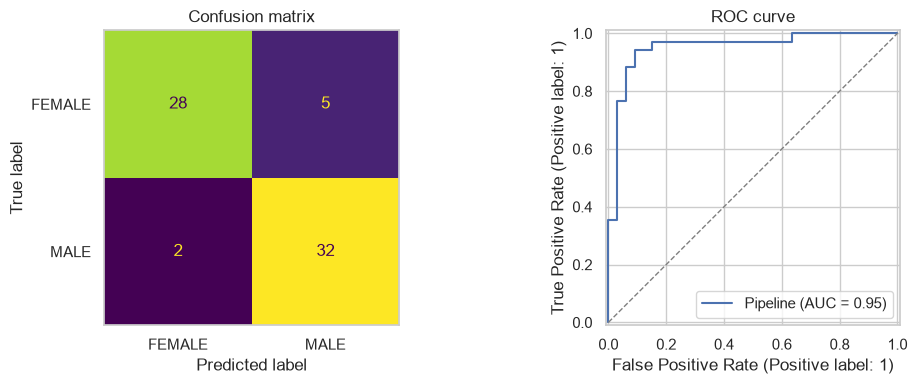

In [23]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
)

print(
    classification_report(
        y_test, classifier.predict(X_test), target_names=["FEMALE", "MALE"]
    )
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_estimator(
    classifier,
    X_test,
    y_test,
    display_labels=["FEMALE", "MALE"],
    ax=axes[0],
    colorbar=False,
)
axes[0].grid(False)
axes[0].set_title("Confusion matrix")
RocCurveDisplay.from_estimator(classifier, X_test, y_test, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "--", color="grey", linewidth=1)
axes[1].set_title("ROC curve")
plt.tight_layout()
plt.show()

The confusion matrix shows exactly which mistakes were made and in which
direction. The ROC curve sweeps the threshold across every possible value and
plots the trade-off, and the area underneath it summarises the model's ranking
ability in a single number that does not depend on the threshold you eventually
pick. An area of 0.5 is a coin toss and 1.0 is perfect.

## 5. Decision Trees And Random Forests (10 Minutes)

Linear models draw one straight boundary. A decision tree instead asks a
sequence of yes or no questions about single features, which lets it carve out
regions of any shape. It is also the only model here that a non-specialist can
read directly.

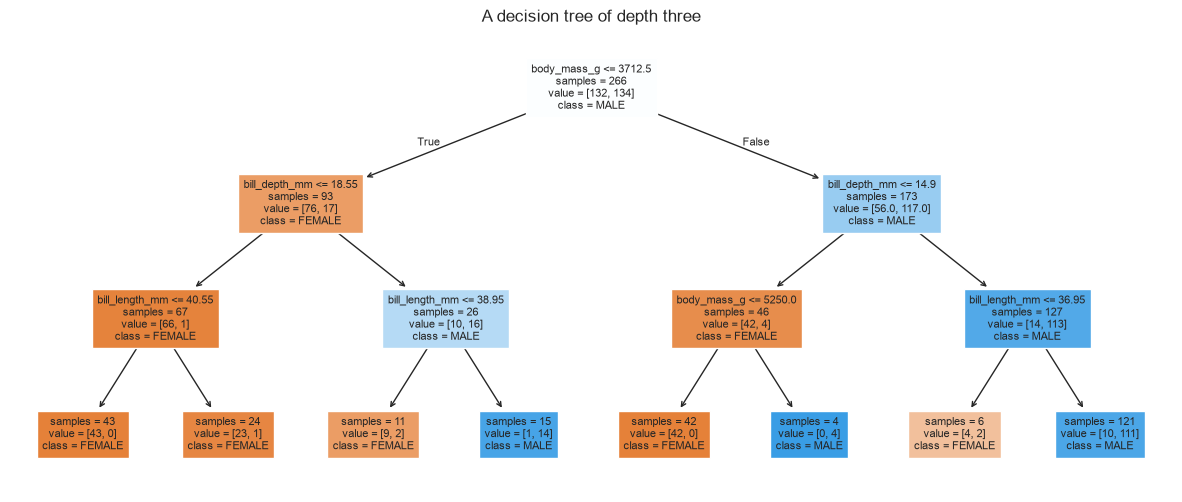

In [24]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

plt.figure(figsize=(15, 6))
plot_tree(
    tree,
    feature_names=list(features.columns),
    class_names=["FEMALE", "MALE"],
    filled=True,
    fontsize=8,
    impurity=False,
)
plt.title("A decision tree of depth three")
plt.show()

Start at the top and follow the branches. Each box states the question, how
many training penguins reached it, and how they were distributed. The path down
to any leaf is a rule you could apply with a ruler and a notebook.

### Where Overfitting Comes From

A tree deep enough to ask enough questions can isolate every individual
training penguin and score perfectly on the data it learned from. That is
memorisation rather than learning, and the held-out set exposes it immediately.

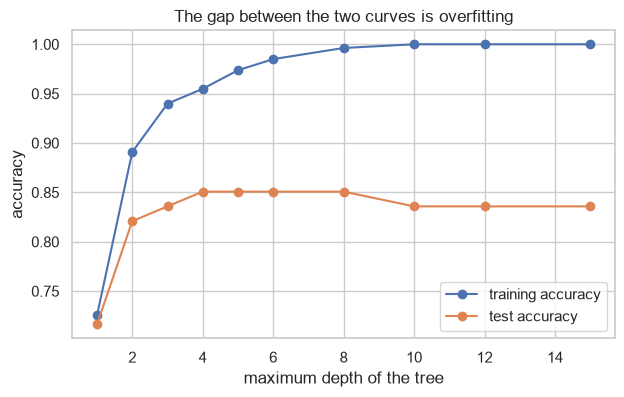

,depth,training accuracy,test accuracy
0,1,0.726,0.716
1,2,0.891,0.821
2,3,0.940,0.836
3,4,0.955,0.851
4,5,0.974,0.851
5,6,0.985,0.851
6,8,0.996,0.851
7,10,1.000,0.836
8,12,1.000,0.836
9,15,1.000,0.836


In [25]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, 12, 15]

scores = []
for depth in depths:
    candidate = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    candidate.fit(X_train, y_train)
    scores.append(
        (depth, candidate.score(X_train, y_train), candidate.score(X_test, y_test))
    )

curve = pd.DataFrame(scores, columns=["depth", "training accuracy", "test accuracy"])

plt.figure(figsize=(7, 4))
plt.plot(
    curve["depth"], curve["training accuracy"], marker="o", label="training accuracy"
)
plt.plot(curve["depth"], curve["test accuracy"], marker="o", label="test accuracy")
plt.xlabel("maximum depth of the tree")
plt.ylabel("accuracy")
plt.title("The gap between the two curves is overfitting")
plt.legend()
plt.show()

curve.round(3)

The training curve climbs to a perfect 1.0 and stays there. The test curve
rises, flattens out somewhere around a depth of four, and then falls back once
the tree passes a depth of eight. Everything to the right of that plateau is
the model learning the noise in the training set.

This picture is the reason the held-out set exists. Judged on training accuracy
alone, the deepest tree is flawless and you would ship it.

### Averaging Many Trees

A random forest fits hundreds of trees, each on a random subset of the rows and
considering a random subset of the features at each split, and averages their
votes. The individual trees still overfit, but they overfit differently, and
averaging cancels much of the error out.

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

forest = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
forest.fit(X_train, y_train)

print(
    f"Single tree, depth 5: {DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE).fit(X_train, y_train).score(X_test, y_test):.3f}"
)
print(f"Random forest:        {forest.score(X_test, y_test):.3f}")
print(f"Logistic regression:  {classifier.score(X_test, y_test):.3f}")

Single tree, depth 5: 0.851
Random forest:        0.896
Logistic regression:  0.896


### One Split Is Not Enough Evidence

Every score so far rests on a single arbitrary split of 67 penguins. Cross
validation repeats the exercise with each part of the data taking a turn as the
test set, which gives both an average and a spread.

In [27]:
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fold_scores = cross_val_score(forest, features, target, cv=folds)

print("Accuracy on each fold:", fold_scores.round(3))
print(f"Mean {fold_scores.mean():.3f}, standard deviation {fold_scores.std():.3f}")

Accuracy on each fold: [0.881 0.91  0.881 0.97  0.955]
Mean 0.919, standard deviation 0.037


The spread across folds is the amount by which your single-split score could
have landed differently through luck alone. When you compare two models, that
spread is the bar the difference between them has to clear.

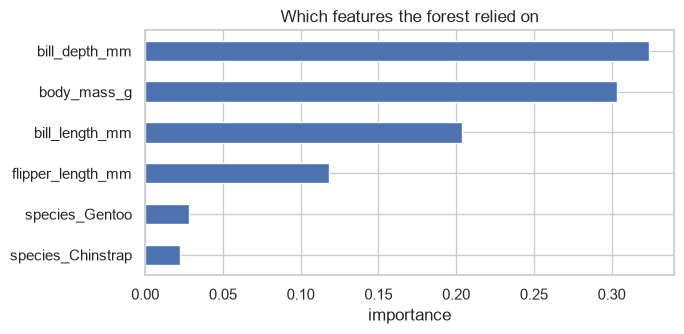

In [28]:
importances = pd.Series(
    forest.feature_importances_, index=features.columns
).sort_values()

plt.figure(figsize=(7, 3.5))
importances.plot.barh()
plt.xlabel("importance")
plt.title("Which features the forest relied on")
plt.tight_layout()
plt.show()

Bill depth and body mass did most of the work in separating males from females.

Treat these numbers as a rough guide rather than a measurement. They report how
often a feature was useful for splitting inside this particular forest. When
two features are strongly correlated the forest can use either one, so the
importance gets shared arbitrarily between them and a genuinely useful feature
can appear unimportant.

## 6. What To Take Away? (1 Minute)

- Look at the table before you model it. Count the missing values, read the
  minimum and maximum of every numeric column, and plot the distributions.
- The median survives bad data that destroys the mean.
- Check every correlation again inside each group, because pooling groups can
  reverse the sign of the answer.
- Split the data before you fit, and score only on the part the model never
  saw.
- Print a baseline next to every score, because a number with no scale attached
  cannot be interpreted.
- The gap between training accuracy and test accuracy is overfitting, and a
  single held-out split is the cheapest way to see it.
- Cross validation tells you how much your score could have moved by luck,
  which is what makes a comparison between two models meaningful.

The laboratory exercise applies this same sequence to a larger and considerably
messier dataset of wine measurements, where several of these habits catch
problems that would otherwise go unnoticed.